In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy
import scipy.io as sio
import time
import open3d as o3d
#import helpers 
import utils
from numba import njit, prange

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
@njit(fastmath=True, parallel=True)
def matched_filter_2d(raw_data_2d, x_cells, z_cells, y_cells, x_radar_tx, x_radar_rx, z_radar_tx, z_radar_rx, lm, slope, sample_rate):
    """
    Implements Algorithm 3 for 2D matched filtering to generate a radar heatmap in Cartesian coordinates.
    
    Parameters:
    - raw_data_2d: Raw radar data (shape: (320, 369, 512))
    - x_cells: X-axis grid points (azimuth)
    - z_cells: Z-axis grid points (elevation)
    - y_fixed: Fixed depth slice
    - x_radar_tx: Transmitter x-positions (shape: (1, 80))
    - x_radar_rx: Receiver x-positions (shape: (320, 1))
    - z_radar_tx: Transmitter z-positions (shape: (1, 369))
    - z_radar_rx: Receiver z-positions (shape: (1, 369))
    - radar_params: Radar parameters (wavelength, sample rate, slope, etc.)
    
    Returns:
    - MF_output: 2D matched filter output (size: len(x_cells) x len(z_cells))
    """

    # Get radar parameters
    c = 3e8  # Speed of light (m/s)

    time_samples = np.arange(100, 140)/sample_rate

    MF_output = np.zeros((len(x_cells), len(z_cells), len(y_cells)), dtype=np.complex64)


    for x_i in prange(len(x_cells)):  
        x = x_cells[x_i]
        for z_i in prange(len(z_cells)): 
            z = z_cells[z_i]
            print(f"z:{z_i} / {len(z_cells)}, x:{x_i} / {len(x_cells)}")
            for y_i in range(len(y_cells)):  # Keep inner loops serial for cache efficiency
                y = y_cells[y_i]
                for m in range(len(x_radar_tx)):
                    for k_i in range(len(z_radar_tx)):
                        for t_i in range(len(time_samples)):
                            t_idx = time_samples[t_i]

                            # Compute distances
                            distances_rx = np.sqrt((x - x_radar_rx[m])**2 + y**2 + (z - z_radar_rx[k_i])**2)
                            distances_tx = np.sqrt((x - x_radar_tx[m])**2 + y**2 + (z - z_radar_tx[k_i])**2)
                            distances = distances_rx + distances_tx

                            # Compute phase
                            phase_shifts = np.exp(-1j * 2 * np.pi * (slope*t_idx / c + 1 / lm) * distances)

                            # Apply matched filter
                            MF_output[x_i, z_i, y_i] += np.sum(raw_data_2d[m, k_i, t_i] * phase_shifts)

    return MF_output

Load data.

In [3]:
# TODO: Put the *path* to the project folder
data_path = r"/home/tim/Documents/EPFL/COM-304-Radars/record/rdc_hand.mat"
#data_path = r"/home/tim/Documents/EPFL/COM-304-Radars/homework/given_data/data_003_.mat"


# loading data that is given
"""
    raw_data: is the raw radar data (after mixing) of size (num_x_stp x num_rx, num_z_stp, adc_samples)
    radar_params: is a dictionary with radar and position parameters: 'sample_rate', 'num_samples', 'slope', 'lm'(lambda), 'num_x_stp', 'num_z_stp', 'num_tx', 'num_rx', 'adc_samples' 
"""
radar_params, raw_data = utils.load_raw_data(data_path)

Defining antenna positions.

In [4]:
x_ant_pos, z_ant_pos, x_ant = utils.get_ant_pos_2d(radar_params['num_x_stp'], radar_params['num_z_stp'], radar_params['num_rx']) # this returns x position of rx, z positions of rx and tx, and x position of tx

Process raw data for MF algorthim (use all samples now).

In [5]:
# Process raw data for MF algorithm (use all samples now)
X = raw_data.reshape((radar_params['num_x_stp'], radar_params['num_z_stp'], radar_params['adc_samples']))

Define the x,y,z voxels to calculate and the radars transmitter and receiver positions in x and z. Then run your algorithm. We recommend processing at lower resolution (eg. 0.05) or smaller portions of space for debugging.

In [6]:
res = 0.01  # Spatial resolution = 1 cm

dataset = 0

if dataset == "data_001":
    x_min, x_max = -0.265, 0.465
    z_min, z_max = -0.22, 0.175
    y_fixed = 5.035  # Y slice for debugging

elif dataset == "data_003":
    x_min, x_max = -0.12, 0.46 
    z_min, z_max = -0.40, 0.25
    y_fixed = 4.3  # Y slice for debugging

elif dataset == "data_010":
    x_min, x_max = -0.23, 0.22
    z_min, z_max = -0.185, 0.24 
    y_fixed = 4.45  # Y slice for debugging

else:
    x_min, x_max = -1., 1.
    z_min, z_max = -1., 1.
    y_fixed = 0.3 

# Compute number of voxels in x and z based on limits
x_cells = np.arange(x_min, x_max, res)  # X-axis grid points
z_cells = np.arange(z_min, z_max, res)  # Z-axis grid points
y_cells = np.array([y_fixed])  # 1 slice depth for debugging

# Define radar transmitter and receiver positions
x_radar_tx = x_radar_tx = np.repeat(x_ant, 4)  # Correct: x_ant for TX
x_radar_rx = x_ant_pos  # Correct: x_ant_pos for RX
z_radar_tx = z_ant_pos.reshape(radar_params['num_z_stp'])  # z_ant_pos for TX
z_radar_rx = z_ant_pos.reshape(radar_params['num_z_stp'])  # z_ant_pos for RX

print(f"Using dataset: {dataset}")
print(f"x range: {x_min} to {x_max}, num_x_cells: {len(x_cells)}")
print(f"z range: {z_min} to {z_max}, num_z_cells: {len(z_cells)}")
print(f"y_fixed (depth slice): {y_fixed}")

# Run matched filter algorithm
lm = radar_params['lm']  # Wavelength (λ)
slope = radar_params['slope']
sample_rate = radar_params['sample_rate']
MF_output = matched_filter_2d(X, x_cells, z_cells, y_cells, x_radar_tx, x_radar_rx, z_radar_tx, z_radar_rx, lm, slope, sample_rate)


Using dataset: 0
x range: -1.0 to 1.0, num_x_cells: 200
z range: -1.0 to 1.0, num_z_cells: 200
y_fixed (depth slice): 0.3


KeyboardInterrupt: 

Plot your outputs below.

MF_output shape: (200, 200, 1)
to_plot shape: (200, 200)


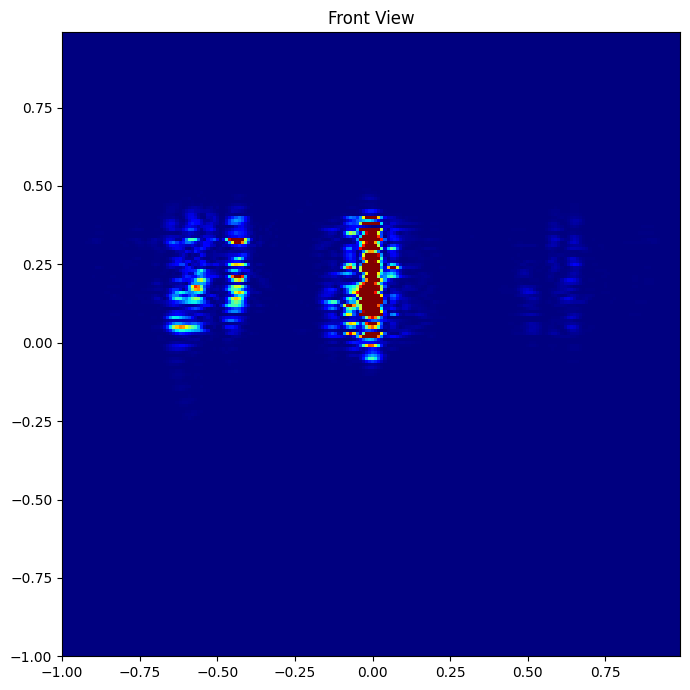

In [42]:
# Plot the output from MF (You can change this as you see fit (this will just plot the front of the object as we are not processing the entire heatmap)

fig = plt.figure(figsize=(7, 7))
to_plot = np.sum(abs(MF_output),axis=-1) # for 2D MF_output (debugging)
#to_plot = np.sum(abs(MF_output), axis=-1) # for 3D MF_output
print(f"MF_output shape: {MF_output.shape}")
print(f"to_plot shape: {to_plot.shape}")
to_plot = to_plot/np.max(np.reshape(to_plot,(1,-1))) 
to_plot = to_plot**2
ax0 = fig.add_subplot(111)


utils.plot_2d_heatmap(ax0, to_plot, x_cells, z_cells, vmin=0, vmax=0.1)
#utils.plot_2d_heatmap(ax0, to_plot, num_x_cells, num_z_cells, vmin=0, vmax=0.1)
ax0.title.set_text('Front View')

plt.tight_layout()
plt.show()
